In [2]:
from ase.io import read

Atoms(symbols='Zn2O2', pbc=True, cell=[[3.269256793208178, 0.0, 0.0], [-1.634628396604089, 2.831258114338113, 0.0], [0.0, 0.0, 5.276580464238]], calculator=SinglePointDFTCalculator(...))
HEX(a=3.26926, c=5.27658)
  Variant name: HEX
  Special point names: GMKALH
  Default path: GMKGALHA,LM,KH

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    M   0.5000  0.0000  0.0000
    K   0.3333  0.3333  0.0000
    A   0.0000  0.0000  0.5000
    L   0.5000  0.0000  0.5000
    H   0.3333  0.3333  0.5000



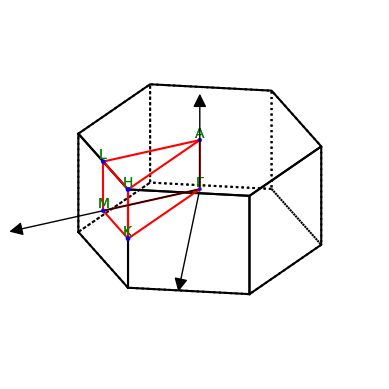

In [16]:
atoms = read('nscf.ZnO_hubbard.out')
lat = atoms.cell.get_bravais_lattice()

print(atoms)
print(lat.description())
lat.plot_bz(show=True);

In [13]:
! grep -A50 'K_POINTS' nscf.ZnO_hubbard.in

K_POINTS (crystal)
  36
 0.0000  0.0000  0.0000 1 !G
 0.1000  0.0000  0.0000 1
 0.2000  0.0000  0.0000 1
 0.3000  0.0000  0.0000 1
 0.4000  0.0000  0.0000 1
 0.5000  0.0000  0.0000 1 !M
 0.5000  0.0000  0.1000 1
 0.5000  0.0000  0.2000 1
 0.5000  0.0000  0.3000 1
 0.5000  0.0000  0.4000 1
 0.5000  0.0000  0.5000 1 !L
 0.4000  0.0000  0.5000 1
 0.3000  0.0000  0.5000 1
 0.2000  0.0000  0.5000 1
 0.1000  0.0000  0.5000 1
 0.0000  0.0000  0.5000 1 !A
 0.0000  0.0000  0.4000 1
 0.0000  0.0000  0.3000 1
 0.0000  0.0000  0.2000 1
 0.0000  0.0000  0.1000 1
 0.0000  0.0000  0.0000 1 !G
 0.1333  0.0666  0.0000 1
 0.2666  0.1333  0.0000 1
 0.3999  0.1999  0.0000 1
 0.5333  0.2666  0.0000 1
 0.6666  0.3333  0.0000 1 !K
 0.6666  0.3333  0.1000 1
 0.6666  0.3333  0.2000 1
 0.6666  0.3333  0.3000 1
 0.6666  0.3333  0.4000 1
 0.6666  0.3333  0.5000 1 !H
 0.5333  0.2666  0.5000 1
 0.3999  0.1999  0.5000 1
 0.2666  0.1333  0.5000 1
 0.1333  0.0666  0.5000 1
 0.0000  0.0000  0.5000 1 !A


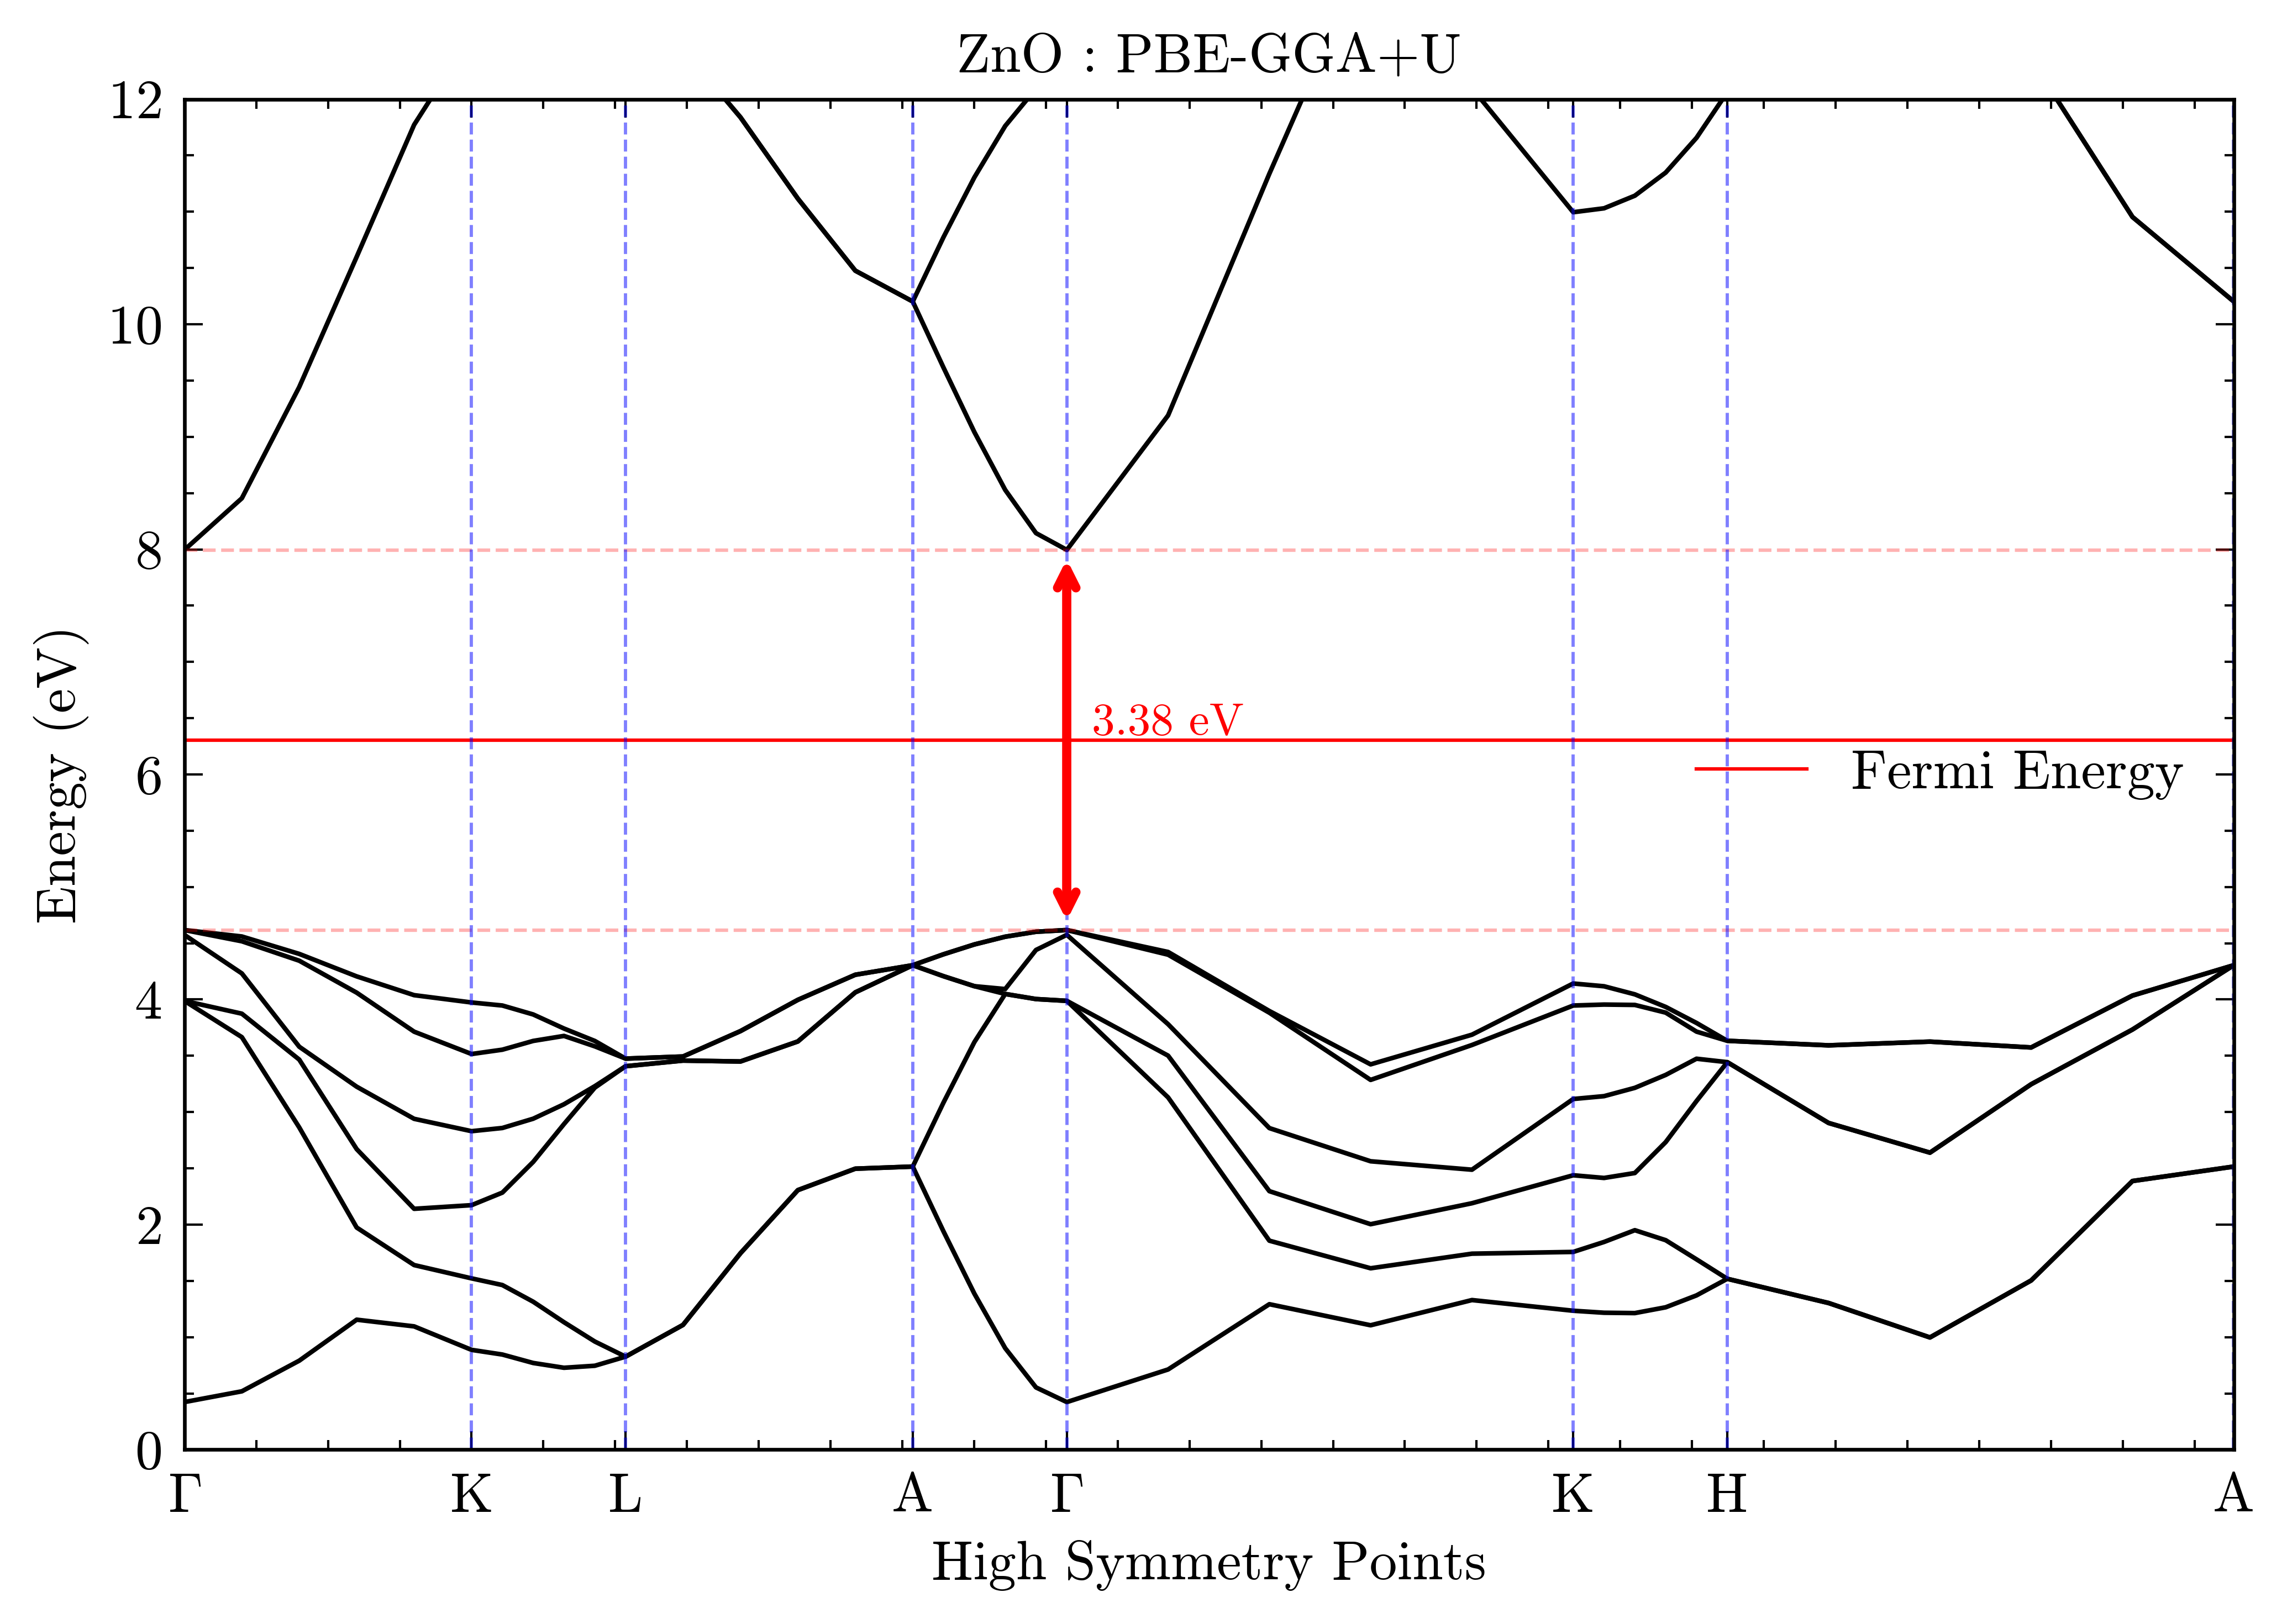

In [33]:
import numpy as np 
import matplotlib.pyplot as plt



# Locais onde estão armazenados os dados
bands_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/Hubbard_Tests/band_structure/ZnO-band-gap-U.bands.gnu"

scientific_theme_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/mpl_themes/computermodern.mplstyle"

plt.style.use(scientific_theme_path)

# Reading Band Structure data
bands = np.loadtxt(bands_path)  # shape=(2592, 2)
k = np.unique(bands[:, 0])

bands = np.reshape(
    bands[:, 1],
    (-1, k.size)
)


high_sym_points = [0.0000,0.5774, 0.8871, 1.4644, 1.7741, 2.7924, 3.1021, 4.1204]
high_sym_points_labels = [r'$\Gamma$',r'K','L', 'A', r'$\Gamma$', 'K', 'H', 'A']



fig, ax = plt.subplots(figsize=(7, 5), dpi=600)
ax.set_title("ZnO : PBE-GGA+U")
for band in range(len(bands)):
    ax.plot(k, bands[band,:], linewidth=1, color='k')

#  Ticks and labels for high-symmetry points
# ax.set_title('Electronic Band Structure')
ax.set_xlabel('High Symmetry Points')
ax.set_ylabel('Energy (eV)')
ax.set_ylim([0, 12])
ax.set_xlim(k.min(), k.max())
ax.set_xticks(high_sym_points)
ax.set_xticklabels(high_sym_points_labels)

banda_cond, banda_val = 7.9952, 4.6176 
ax.annotate(
    '', xy=(high_sym_points[4], banda_cond), xytext=(high_sym_points[4], banda_val),
    arrowprops=dict(arrowstyle='<->', color='red', linewidth=2)
)
ax.text(
high_sym_points[4] + 0.05, (banda_cond + banda_val)/2+0.15,
f'{banda_cond - banda_val:.2f} eV',
va='center', color='red'
)

# Linhas Horizontais para banda de condução, valência e Fermi
ax.axhline((banda_cond+banda_val)/2, linewidth=0.75, color='red', alpha=1, linestyle='-', label="Fermi Energy") 
ax.axhline(banda_cond, linewidth=0.75, color='red', alpha=0.3, linestyle='--') #
ax.axhline(banda_val, linewidth=0.75, color='red', alpha=0.3, linestyle='--')

# Vertical Lines on high symmetry values
for value in high_sym_points:
    ax.axvline(value, color='blue', linestyle='--', linewidth=0.7, alpha=0.5)

ax.legend(fontsize=12)

plt.tight_layout()

In [24]:
! grep highest scf.ZnO_hubbard.out

     highest occupied, lowest unoccupied level (ev):     4.6176    7.9952


<h1> Comparasion with no Hubbard Correction </h1>

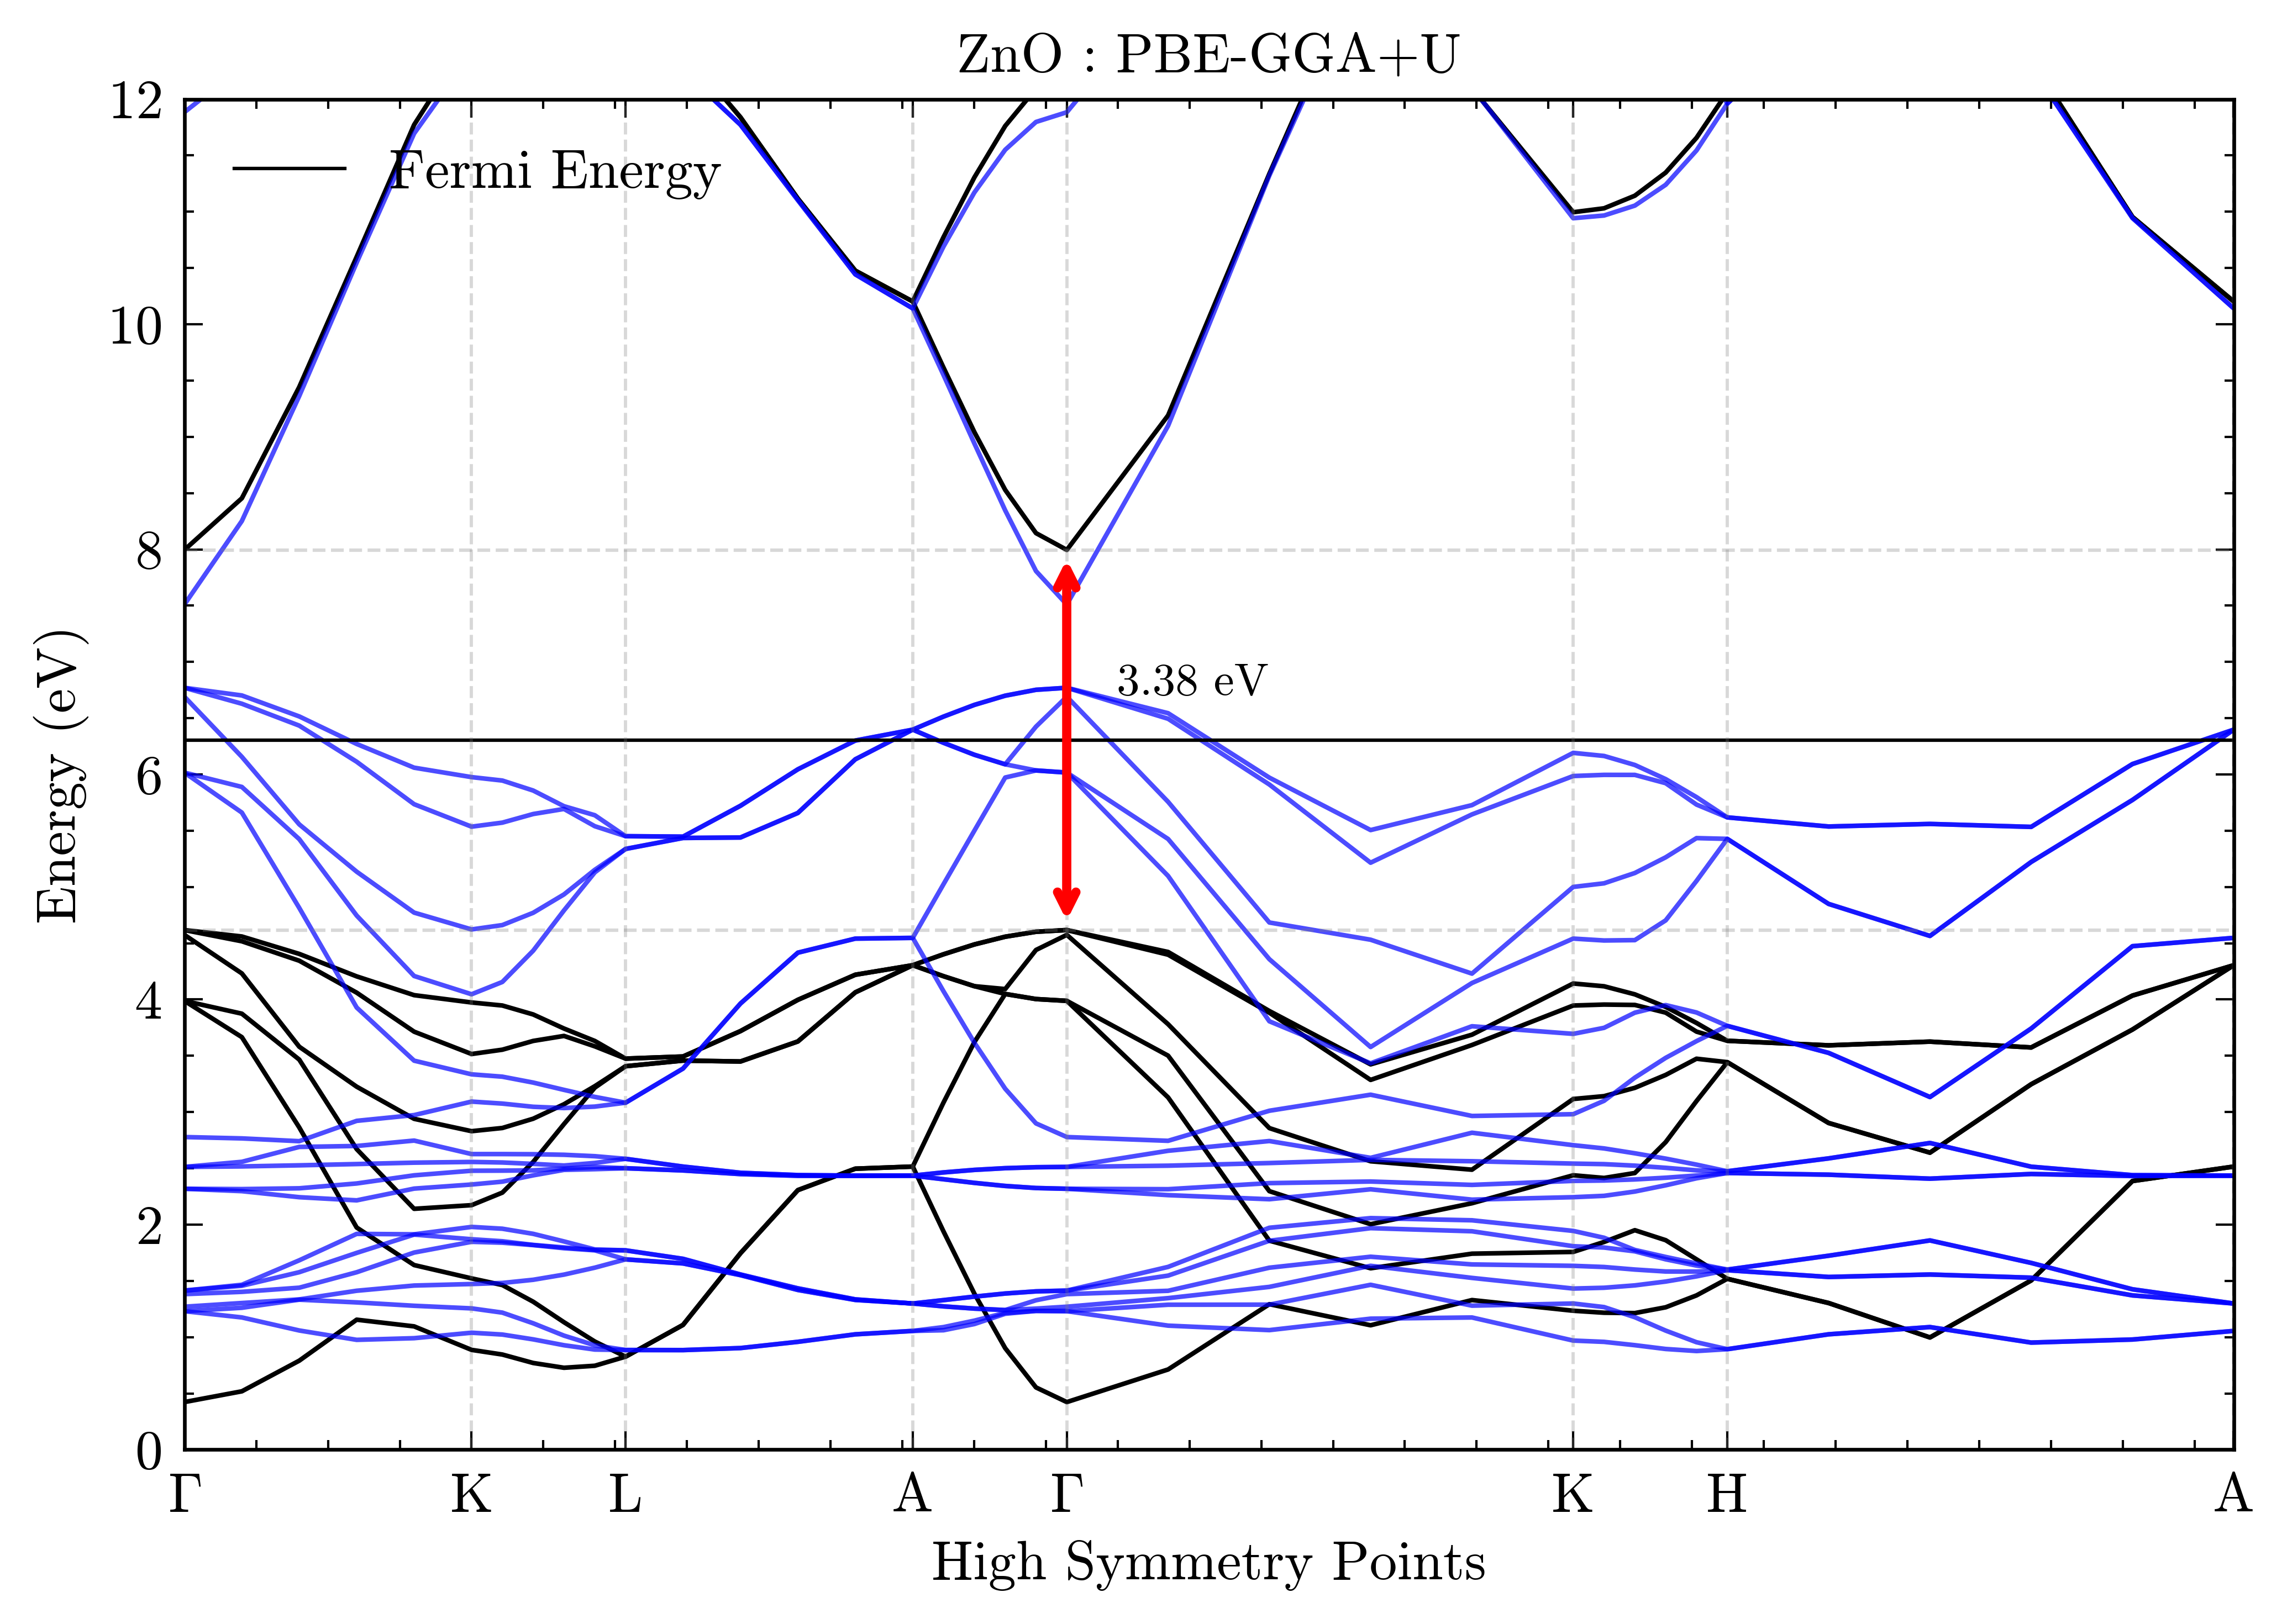

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt



# Locais onde estão armazenados os dados
bands_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/Hubbard_Tests/band_structure/ZnO-band-gap-U.bands.gnu"
bands_pbe_gga = r"/home/jvc/QEspresso7.2/ZnO_database/ZnO_system_preparation/data/pw_fixed_occupations/ZnO-fixed_bands.dat.gnu"
scientific_theme_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/mpl_themes/computermodern.mplstyle"

plt.style.use(scientific_theme_path)

# Reading Band Structure data
# GGA+U
bands = np.loadtxt(bands_path)  # shape=(2592, 2)
k = np.unique(bands[:, 0])
bands = np.reshape(
    bands[:, 1],
    (-1, k.size)
)
# GGA
bands_gga = np.loadtxt(bands_pbe_gga)
k_bands_gga = np.unique(bands_gga[:, 0])
bands_gga = np.reshape(bands_gga[:, 1], (-1, k_bands_gga.size))



high_sym_points = [0.0000,0.5774, 0.8871, 1.4644, 1.7741, 2.7924, 3.1021, 4.1204]
high_sym_points_labels = [r'$\Gamma$',r'K','L', 'A', r'$\Gamma$', 'K', 'H', 'A']



fig, ax = plt.subplots(figsize=(7, 5), dpi=600)
ax.set_title("ZnO : PBE-GGA+U")

for band in range(len(bands)):
    ax.plot(k, bands[band,:], linewidth=1, color='k')

for band in range(len(bands_gga)):
    ax.plot(k, bands_gga[band,:], linewidth=1, color='blue', alpha=0.7)


#  Ticks and labels for high-symmetry points
# ax.set_title('Electronic Band Structure')
ax.set_xlabel('High Symmetry Points')
ax.set_ylabel('Energy (eV)')
ax.set_ylim([0, 12])
ax.set_xlim(k.min(), k.max())
ax.set_xticks(high_sym_points)
ax.set_xticklabels(high_sym_points_labels)

banda_cond, banda_val = 7.9952, 4.6176 
ax.annotate(
    '', xy=(high_sym_points[4], banda_cond), xytext=(high_sym_points[4], banda_val),
    arrowprops=dict(arrowstyle='<->', color='red', linewidth=2)
)
ax.text(high_sym_points[4] + 0.10, (banda_cond + banda_val)/2+.50, f'{banda_cond - banda_val:.2f} eV',
va='center', color='k'
)

# Linhas Horizontais para banda de condução, valência e Fermi
ax.axhline((banda_cond+banda_val)/2, linewidth=0.75, color='k', alpha=1, linestyle='-', label="Fermi Energy") 
ax.axhline(banda_cond, linewidth=0.75, color='gray', alpha=0.3, linestyle='--') #
ax.axhline(banda_val, linewidth=0.75, color='gray', alpha=0.3, linestyle='--')

# Vertical Lines on high symmetry values
for value in high_sym_points:
    ax.axvline(value, color='gray', linestyle='--', linewidth=0.7, alpha=0.3)

ax.legend(fontsize=12)

plt.tight_layout()